<a href="https://colab.research.google.com/github/tomasbelak24/deeplearning-vision/blob/main/hw1/best_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Best model

1. config:
- deep net with BN
- default adam
- batch size 64
- medium augmentation


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
from matplotlib import pyplot as plt

100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]


torch.Size([1, 3, 32, 32])


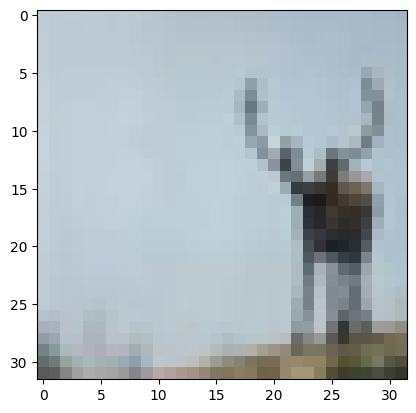

tensor([4])
deer
torch.Size([1, 3, 32, 32])


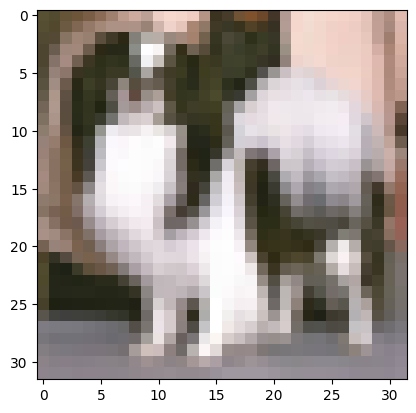

tensor([5])
dog
torch.Size([1, 3, 32, 32])


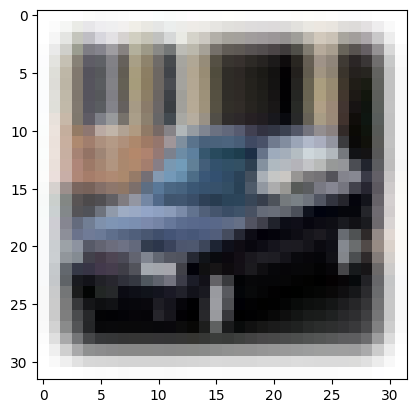

tensor([1])
car
torch.Size([1, 3, 32, 32])


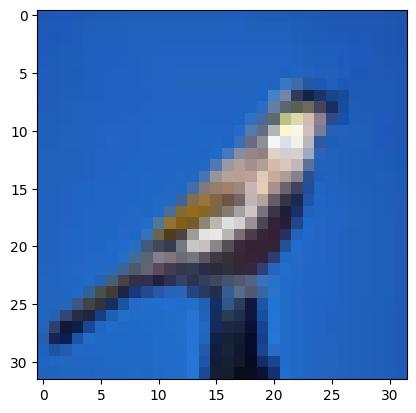

tensor([2])
bird
torch.Size([1, 3, 32, 32])


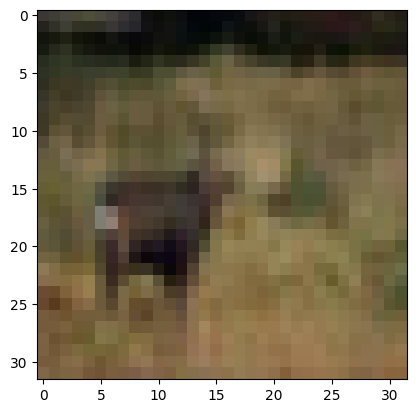

tensor([4])
deer
torch.Size([1, 3, 32, 32])


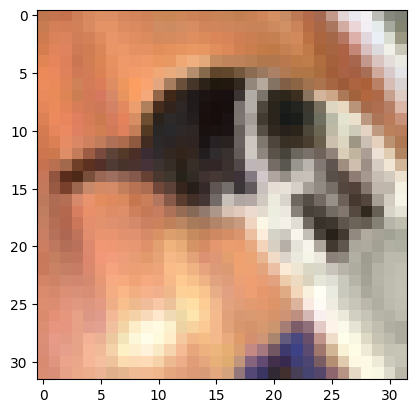

tensor([3])
cat
torch.Size([1, 3, 32, 32])


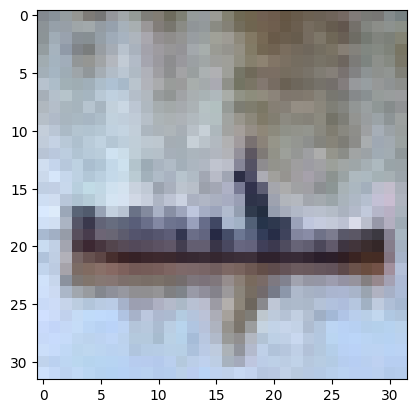

tensor([8])
ship
torch.Size([1, 3, 32, 32])


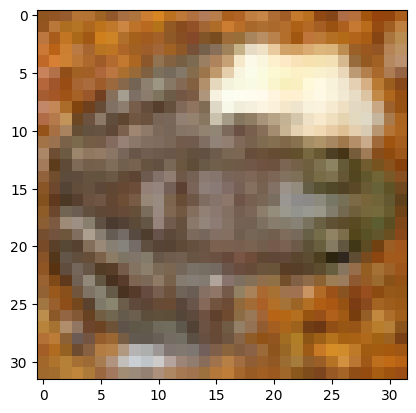

tensor([6])
frog
torch.Size([1, 3, 32, 32])


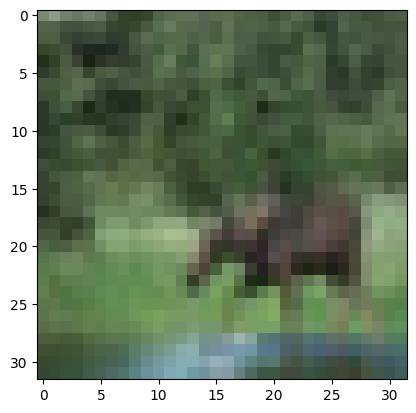

tensor([4])
deer
torch.Size([1, 3, 32, 32])


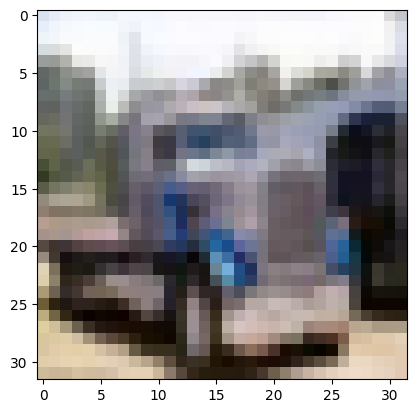

tensor([9])
truck
torch.Size([1, 3, 32, 32])


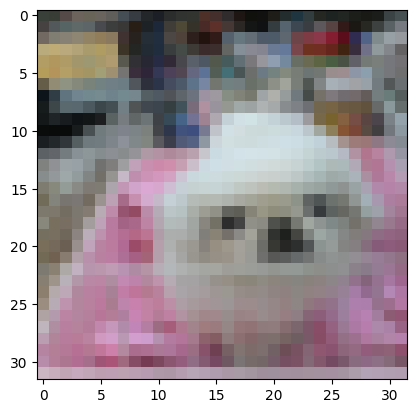

tensor([5])
dog


In [ ]:
# @title Loading CIFAR10 dataset

#reused code from the 5th lab

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# for reproducibility
trainset, valset = torch.utils.data.random_split(dataset, [45000, 5000], generator=torch.Generator().manual_seed(42))

previewloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

for i, sample in enumerate(previewloader):
  if i > 10:
    break
  x, y = sample
  print(x.shape)
  img = np.moveaxis(x.numpy()[0], 0, -1)
  plt.imshow(img)
  plt.show()
  print(y)
  print(classes[y.item()])

### Model architecture and training

In [ ]:
from torch.nn import Sequential, Linear, ReLU, Softmax, Conv2d, MaxPool2d, Flatten, AdaptiveAvgPool2d, BatchNorm2d

#9 conv, 2 fc, batchnorm
def build_model(num_classes=10):
    model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True),
        BatchNorm2d(32),
        ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True),
        BatchNorm2d(32),
        ReLU(),
        Conv2d(32, 32, 3, padding=1, bias=True),
        BatchNorm2d(32),
        ReLU(),
        MaxPool2d(2),

        Conv2d(32, 64, 3, padding=1, bias=True),
        BatchNorm2d(64),
        ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True),
        BatchNorm2d(64),
        ReLU(),
        Conv2d(64, 64, 3, padding=1, bias=True),
        BatchNorm2d(64),
        ReLU(),
        MaxPool2d(2),

        Conv2d(64, 128, 3, padding=1, bias=True),
        BatchNorm2d(128),
        ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True),
        BatchNorm2d(128),
        ReLU(),
        Conv2d(128, 128, 3, padding=1, bias=True),
        BatchNorm2d(128),
        ReLU(),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, 64),
        ReLU(),
        Linear(64, num_classes)
    )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference

model, model_inference = build_model()

out = model_inference(torch.from_numpy(np.zeros([1, 3, 32, 32], dtype=np.float32)))
print(out.size())
print(out)
print(classes[out.argmax().item()])

torch.Size([1, 10])
tensor([[0.0729, 0.1196, 0.0725, 0.0835, 0.1528, 0.0904, 0.1102, 0.0940, 0.0824,
         0.1216]], grad_fn=<SoftmaxBackward0>)
deer


In [ ]:
medium_transform = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
])

In [ ]:
dataset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=medium_transform)
trainset_aug, _ = torch.utils.data.random_split(dataset_aug, [45000, 5000], generator=torch.Generator().manual_seed(42))

In [ ]:
def one_epoch(model, loss, optimizer, dataloader_train, dataloader_val, verbose=True):
  train_losses = []
  val_losses = []

  model.train()
  for i, batch in enumerate(dataloader_train):
    x, y = batch[0].to(device), batch[1].to(device)
    optimizer.zero_grad()

    out = model(x)
    loss = ce_loss(out, y)
    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()
    if i % 100 == 0 and verbose:
      print("Training loss at step {}: {}".format(i, loss.item()))

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for i, batch in enumerate(dataloader_val):
      x, y = batch[0].to(device), batch[1].to(device)

      out = model(x)
      loss = ce_loss(out, y)
      acc = torch.sum(torch.argmax(out, dim=-1) == y)
      correct += acc.item()
      total += len(batch[1])
      val_losses.append(loss.item())

  val_acc = correct / total

  return np.mean(train_losses), np.mean(val_losses), val_acc

Using device:  cuda:0
Val loss at epoch 0: 1.1662340028376519
Val acc at epoch 0: 0.5786
Val loss at epoch 1: 0.8981857118727286
Val acc at epoch 1: 0.6768
Val loss at epoch 2: 0.7355631107016455
Val acc at epoch 2: 0.7394
Val loss at epoch 3: 0.7024287530515767
Val acc at epoch 3: 0.759
Val loss at epoch 4: 0.6495812061843993
Val acc at epoch 4: 0.7804
Val loss at epoch 5: 0.6889319910278803
Val acc at epoch 5: 0.7604
Val loss at epoch 6: 0.6079075858940052
Val acc at epoch 6: 0.7892
Val loss at epoch 7: 0.5741308314985112
Val acc at epoch 7: 0.8028
Val loss at epoch 8: 0.582630905923964
Val acc at epoch 8: 0.8032
Val loss at epoch 9: 0.5579834938803806
Val acc at epoch 9: 0.8076
Val loss at epoch 10: 0.4811684960805917
Val acc at epoch 10: 0.8334
Val loss at epoch 11: 0.4817792805312555
Val acc at epoch 11: 0.8324
Val loss at epoch 12: 0.5423330951812146
Val acc at epoch 12: 0.8216
Val loss at epoch 13: 0.48452041446691074
Val acc at epoch 13: 0.8334
Val loss at epoch 14: 0.508636571

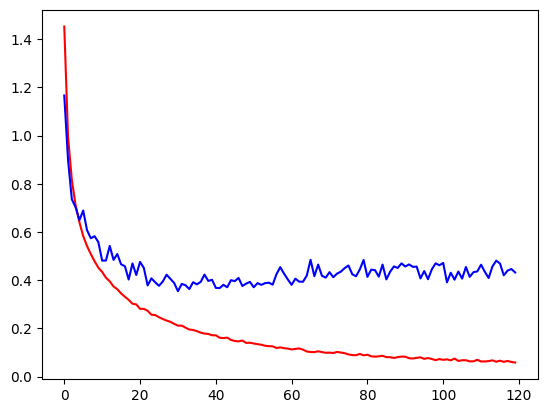

In [ ]:
batch_size = 64

dataloader_train = torch.utils.data.DataLoader(trainset_aug, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

model, model_inference = build_model()

model.to(device)
model_inference.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epoch_train_losses = []
epoch_val_losses = []
epoch_val_accs = []

for e in range(120):
  train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, verbose=False)

  print("Val loss at epoch {}: {}".format(e, val_loss))
  print("Val acc at epoch {}: {}".format(e, val_acc))

  torch.save(model.state_dict(), "{:03d}.pth".format(e))
  epoch_train_losses.append(train_loss)
  epoch_val_losses.append(val_loss)
  epoch_val_accs.append(val_acc)

plt.plot(epoch_train_losses, c='r')
plt.plot(epoch_val_losses, c='b')
plt.show()

In [ ]:
print(f"Last training loss: {epoch_train_losses[-1]}\nLast validation loss: {epoch_val_losses[-1]}\nLast validation accuracy: {epoch_val_accs[-1]}")
print(f"Best training loss: {np.min(epoch_train_losses)} ({np.argmin(epoch_train_losses)})\nBest validation loss: {np.min(epoch_val_losses)} ({np.argmin(epoch_val_losses)})\nBest validation accuracy: {np.max(epoch_val_accs)} ({np.argmax(epoch_val_accs)})")

Last training loss: 0.05883273625725203
Last validation loss: 0.4322248776609084
Last validation accuracy: 0.8974
Best training loss: 0.05883273625725203 (119)
Best validation loss: 0.354417428091357 (30)
Best validation accuracy: 0.9014 (96)


### Plots and baseline comparison

In [ ]:
# @title Dumping losses and val accuracy into json
import json

baseline_results = {
    'train_losses': epoch_train_losses,
    'val_losses': epoch_val_losses,
    'val_accuracies': epoch_val_accs
}

with open('best_results.json', 'w') as f:
    json.dump(baseline_results, f)

print("best results saved to baseline_results.json")

best results saved to baseline_results.json


In [ ]:
import json

with open('best_results.json', 'r') as f:
    loaded_results = json.load(f)

print("best_results.json loaded successfully:")
print(loaded_results.keys())

best_results.json loaded successfully:
dict_keys(['train_losses', 'val_losses', 'val_accuracies'])


In [ ]:
epoch_train_losses = loaded_results['train_losses']
epoch_val_losses = loaded_results['val_losses']
epoch_val_accs = loaded_results['val_accuracies']

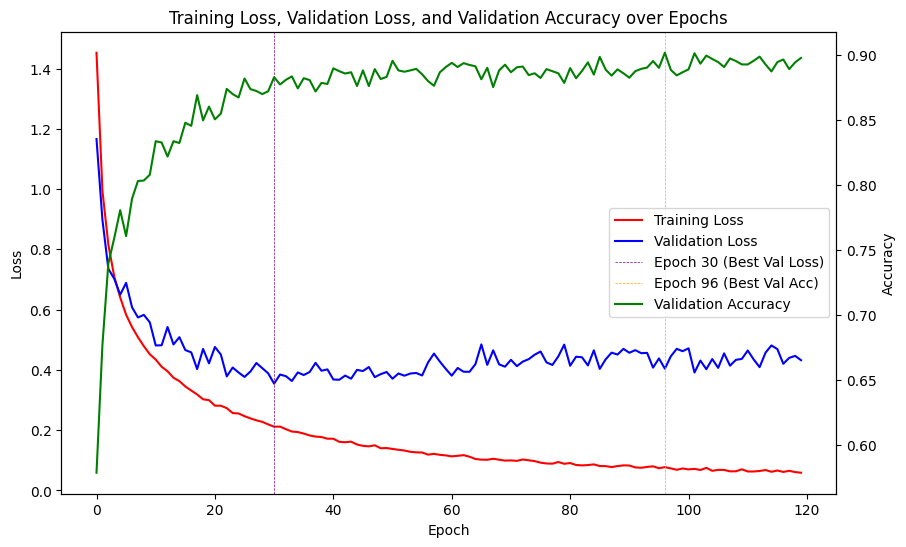

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot losses on the primary y-axis
ax1.plot(epoch_train_losses, c='r', label='Training Loss')
ax1.plot(epoch_val_losses, c='b', label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a secondary y-axis for accuracy
ax2 = ax1.twinx()
ax2.plot(epoch_val_accs, c='g', label='Validation Accuracy')
ax2.set_ylabel('Accuracy')
ax2.tick_params(axis='y')

# Add vertical lines for specific epochs
ax1.axvline(x=30, color='purple', linestyle='--', label='Epoch 30 (Best Val Loss)',linewidth=0.5)
ax1.axvline(x=96, color='orange', linestyle='--', label='Epoch 96 (Best Val Acc)', linewidth=0.5)

# Add title and legend
plt.title('Training Loss, Validation Loss, and Validation Accuracy over Epochs')
fig.legend(loc='center right', bbox_to_anchor=(1, 0.5), bbox_transform=ax1.transAxes)

# plt.grid(True)
plt.show()